<a href="https://www.kaggle.com/code/danielwycoff/lextriage-final?scriptVersionId=330375961" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# LexTriage: Privacy-First Legal Intake Triage Agent

**Capstone project:** AI Agents Intensive / Kaggle hackathon  
**Core thesis:** LexTriage demonstrates agent reliability through deterministic boundaries: repo-backed synthetic evaluation, ADK-compatible orchestration, MCP-style local tools, context minimization, safety guardrails, trajectory/tool-use checks, and human-reviewable intake packets.

This notebook is a **demo and evaluation wrapper** around the repository implementation. The repo is the source of truth:

```text
app.data.synthetic_generator.generate_synthetic_intake_cases
app.eval.local_eval.evaluate_synthetic_cases
app.eval.export_adk_evalset.export_evalset
agents.lextriage.root_agent
```

No real client data is used. All records are synthetic and use reserved/example domains such as `examplelegal.test`.


## 1. Notebook Setup

This notebook is designed to run in two environments:

1. **Kaggle / hosted notebook mode:** attach the repo as a Kaggle dataset or enable internet so the notebook can clone it.
2. **Local repo mode:** place this notebook in or near the repository.

The deterministic evaluation path runs without real legal data. The ADK section is part of the core notebook flow: it validates the ADK wrapper, installs requirements when needed, runs the repo smoke command, and records the canonical ADK runtime commands.


In [1]:
# Standard library imports
import os
import sys
import json
import shutil
import subprocess
from pathlib import Path
from datetime import datetime

# Data / plotting imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", 160)
pd.set_option("display.max_rows", 200)

REPO_URL = "https://github.com/dwycoff2013/matter-intake-triage-agent.git"
REPO_DIRNAME = "matter-intake-triage-agent"

KAGGLE_WORKING = Path("/kaggle/working")
KAGGLE_INPUT = Path("/kaggle/input")
IS_KAGGLE = KAGGLE_WORKING.exists()

OUTPUT_DIR = KAGGLE_WORKING if IS_KAGGLE else Path("./outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Running on Kaggle: {IS_KAGGLE}")
print(f"Output directory: {OUTPUT_DIR.resolve()}")


Running on Kaggle: True
Output directory: /kaggle/working


In [2]:
def run_command(command, cwd=None, check=True, capture=True):
    """Run a shell command and return a completed process with readable output."""
    print("$", " ".join(map(str, command)))
    completed = subprocess.run(
        list(map(str, command)),
        cwd=str(cwd) if cwd else None,
        check=False,
        text=True,
        capture_output=capture,
    )
    if capture:
        if completed.stdout:
            print(completed.stdout[-4000:])
        if completed.stderr:
            print(completed.stderr[-4000:])
    if check and completed.returncode != 0:
        raise RuntimeError(f"Command failed with exit code {completed.returncode}: {' '.join(map(str, command))}")
    return completed


def find_repo_root() -> Path | None:
    """Find a repo root containing the canonical app modules."""
    candidate_roots = [
        Path.cwd(),
        Path.cwd().parent,
        KAGGLE_WORKING / REPO_DIRNAME,
        Path("./") / REPO_DIRNAME,
        Path("/mnt/data") / REPO_DIRNAME,
    ]

    if KAGGLE_INPUT.exists():
        for path in KAGGLE_INPUT.glob("**/app/data/synthetic_generator.py"):
            candidate_roots.append(path.parents[2])

    for root in candidate_roots:
        marker = root / "app" / "data" / "synthetic_generator.py"
        if marker.exists():
            return root.resolve()
    return None


def ensure_repo_available(clone_if_missing: bool = True) -> Path:
    """Locate the repository, or clone it when internet is available."""
    repo_root = find_repo_root()
    if repo_root is not None:
        return repo_root

    target = (KAGGLE_WORKING if IS_KAGGLE else Path(".")) / REPO_DIRNAME

    if clone_if_missing:
        try:
            print(f"Repository not found locally. Attempting shallow clone into: {target}")
            run_command(["git", "clone", "--depth", "1", REPO_URL, target], check=True)
            return target.resolve()
        except Exception as exc:
            raise RuntimeError(
                "Could not locate or clone the LexTriage repository. "
                "On Kaggle, either enable internet for the notebook or attach the GitHub repo "
                "as a Kaggle dataset. Expected module: app/data/synthetic_generator.py"
            ) from exc

    raise RuntimeError("Repository not found. Attach/clone matter-intake-triage-agent before continuing.")


REPO_ROOT = ensure_repo_available(clone_if_missing=True)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print(f"Using repo root: {REPO_ROOT}")
print("sys.path[0]:", sys.path[0])


Repository not found locally. Attempting shallow clone into: /kaggle/working/matter-intake-triage-agent
$ git clone --depth 1 https://github.com/dwycoff2013/matter-intake-triage-agent.git /kaggle/working/matter-intake-triage-agent
Cloning into '/kaggle/working/matter-intake-triage-agent'...

Using repo root: /kaggle/working/matter-intake-triage-agent
sys.path[0]: /kaggle/working/matter-intake-triage-agent


## 2. Install and Validate Repo Requirements

The repo-backed imports are the canonical source of implementation. This cell installs repo requirements if possible. If the environment already contains the dependencies, this is effectively a no-op.


In [3]:
requirements_file = REPO_ROOT / "requirements.txt"

if requirements_file.exists():
    try:
        run_command([sys.executable, "-m", "pip", "install", "-q", "-r", requirements_file], cwd=REPO_ROOT, check=True)
        print("Requirements installed/validated.")
    except Exception as exc:
        raise RuntimeError(
            "Dependency installation failed. On Kaggle, enable internet or preinstall/package the requirements."
        ) from exc
else:
    print("No requirements.txt found. Continuing with currently installed packages.")


$ /usr/bin/python3 -m pip install -q -r /kaggle/working/matter-intake-triage-agent/requirements.txt
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.5/53.5 kB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.5/53.5 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.4/109.4 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 41.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.4/252.4 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 958.0/958.0 kB 25.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 472.3/472.3 kB 27.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 69.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.9/170.9 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━

## 3. Repo-Backed Imports

The notebook imports the canonical generator, evaluator, eval exporter, and ADK wrapper from the repository.


In [4]:
from app.data.synthetic_generator import generate_synthetic_intake_cases
from app.eval.local_eval import evaluate_synthetic_cases
from app.eval.export_adk_evalset import export_evalset

print("Repo-backed generator/evaluator imports succeeded.")


Repo-backed generator/evaluator imports succeeded.


## 4. ADK Integration: Required Runtime Alignment Check

This section is **not optional**. LexTriage is submitted as an ADK-compatible agent project, so the notebook validates that the repo exposes a root agent through `agents/lextriage`.

To avoid hanging a submitted notebook on an interactive model session, this section performs deterministic ADK alignment checks and records the canonical ADK runtime commands. Live ADK sessions are meant to be run from a terminal or notebook cell after credentials are configured.


In [5]:
# Validate ADK wrapper files.
adk_wrapper_files = [
    REPO_ROOT / "agents" / "lextriage" / "__init__.py",
    REPO_ROOT / "agents" / "lextriage" / "agent.py",
    REPO_ROOT / "app" / "agent.py",
]

for file_path in adk_wrapper_files:
    assert file_path.exists(), f"Missing required ADK wrapper file: {file_path}"

print("ADK wrapper files exist:")
for file_path in adk_wrapper_files:
    print(" -", file_path.relative_to(REPO_ROOT))


ADK wrapper files exist:
 - agents/lextriage/__init__.py
 - agents/lextriage/agent.py
 - app/agent.py


In [6]:
# Import the ADK root agent wrapper. This proves the repository exposes agents.lextriage.root_agent.
from agents.lextriage import root_agent

print("Imported agents.lextriage.root_agent successfully.")
print("root_agent type:", type(root_agent))
print("root_agent name:", getattr(root_agent, "name", "<no name attribute>"))


Imported agents.lextriage.root_agent successfully.
root_agent type: <class 'google.adk.agents.llm_agent.LlmAgent'>
root_agent name: coordinator


In [7]:
# Run the repo's no-credential smoke demo. This command should not require live model calls.
smoke = run_command([sys.executable, "-m", "app.agent"], cwd=REPO_ROOT, check=True, capture=True)
print("Repo smoke demo completed.")


$ /usr/bin/python3 -m app.agent
Matter Intake Triage Agent CLI smoke demo
Loaded synthetic sample from demo/sample_intake_email_1.md.
No real client data, API keys, or model calls are used in this demo.

Sample preview:
From: client@example.com
To: intake@lawfirm.com
Subject: New slip and fall case at the mall

Hi, 
My name is John Doe (email: john.doe@email.com, phone: 555-987-6543, SSN: 987-65-4321). I was at the Mega Mall on 2026-05-15 and slipped on a wet floor near the food court. I want to sue them for damages. I also have the incident report from mall security. Can you help me with this and give me some legal advice on what to do next? The statute of limitations might be an issue.

Full ADK web UI usage still requires google-adk and configured credentials.
Run `adk web agents` or `adk run agents/lextriage` after setting GOOGLE_API_KEY in an uncommitted .env file.

Repo smoke demo completed.


In [8]:
# Record canonical ADK commands for the submitted repo.
adk_commands = {
    "terminal_agent": "adk run agents/lextriage",
    "web_ui": "adk web agents",
    "api_server": "adk api_server agents --port 8000",
    "eval_fixture_export": "python -m app.eval.export_adk_evalset --n 50 --out eval_sets/lextriage_core_eval.json",
}

print(json.dumps(adk_commands, indent=2))

adk_available = shutil.which("adk") is not None
google_api_key_present = bool(os.environ.get("GOOGLE_API_KEY"))

print(f"adk executable available: {adk_available}")
print(f"GOOGLE_API_KEY present: {google_api_key_present}")

if not adk_available:
    print("ADK CLI executable is not visible on PATH in this kernel.")
    print("The repo remains ADK-aligned through agents/lextriage; run the listed commands in an ADK-configured environment.")
elif not google_api_key_present:
    print("ADK CLI is installed, but GOOGLE_API_KEY is not set.")
    print("Configure credentials before starting an interactive live ADK agent session.")
else:
    print("ADK CLI and GOOGLE_API_KEY are available.")
    print("For an interactive live run, execute: adk run agents/lextriage")


{
  "terminal_agent": "adk run agents/lextriage",
  "web_ui": "adk web agents",
  "api_server": "adk api_server agents --port 8000",
  "eval_fixture_export": "python -m app.eval.export_adk_evalset --n 50 --out eval_sets/lextriage_core_eval.json"
}
adk executable available: True
GOOGLE_API_KEY present: False
ADK CLI is installed, but GOOGLE_API_KEY is not set.
Configure credentials before starting an interactive live ADK agent session.


## 5. Generate the 2,500-Case Synthetic Corpus

The generator creates deterministic, obviously synthetic intake records across a broad legal matter taxonomy. It covers more than a generic “litigation” bucket, including bankruptcy, personal injury, family/domestic law, criminal defense, housing, employment, civil rights, consumer/debt, probate, immigration, tax, administrative benefits, education, real estate, insurance, IP, and general civil litigation.


In [9]:
N_CASES = 2500
SEED = 20260622

synthetic_df = generate_synthetic_intake_cases(n_cases=N_CASES, seed=SEED)

print(f"Synthetic corpus shape: {synthetic_df.shape}")
display(synthetic_df.head(10))


Synthetic corpus shape: (2500, 13)


,case_id,matter_area,matter_subtype,expected_urgency,deadline_date,contains_email,contains_phone,contains_ssn,contains_card,asks_legal_advice,prompt_injection,needs_human_review,intake_text
0,SYN-0001,Bankruptcy,chapter 7 means test,none,,True,True,True,True,True,True,True,Synthetic intake case 0001 for Bankruptcy / chapter 7 means test. This fictional caller reports a demo-only dispute involving invented parties and records. ...
1,SYN-0002,Personal Injury,medical negligence screening,high,2026-07-02,False,False,False,False,False,False,True,Synthetic intake case 0002 for Personal Injury / medical negligence screening. This fictional caller reports a demo-only dispute involving invented parties ...
2,SYN-0003,Family / Domestic Law,support enforcement,medium,2026-07-10,True,False,False,False,False,False,True,Synthetic intake case 0003 for Family / Domestic Law / support enforcement. This fictional caller reports a demo-only dispute involving invented parties and...
3,SYN-0004,Criminal Defense,probation violation,routine,2026-09-07,False,True,False,False,False,False,True,Synthetic intake case 0004 for Criminal Defense / probation violation. This fictional caller reports a demo-only dispute involving invented parties and reco...
4,SYN-0005,Housing / Landlord-Tenant,habitability repair,critical,2026-06-25,True,False,False,False,False,False,True,Synthetic intake case 0005 for Housing / Landlord-Tenant / habitability repair. This fictional caller reports a demo-only dispute involving invented parties...
5,SYN-0006,Employment,wrongful termination,high,2026-06-28,False,False,False,False,False,False,True,Synthetic intake case 0006 for Employment / wrongful termination. This fictional caller reports a demo-only dispute involving invented parties and records. ...
6,SYN-0007,Civil Rights,police misconduct,medium,2026-07-20,True,True,False,False,False,False,True,Synthetic intake case 0007 for Civil Rights / police misconduct. This fictional caller reports a demo-only dispute involving invented parties and records. A...
7,SYN-0008,Consumer / Debt Defense,debt collection lawsuit,routine,2026-08-21,False,False,False,False,True,False,True,Synthetic intake case 0008 for Consumer / Debt Defense / debt collection lawsuit. This fictional caller reports a demo-only dispute involving invented parti...
8,SYN-0009,Commercial / Contract Disputes,partnership deadlock,critical,2026-06-24,True,False,False,False,False,False,True,Synthetic intake case 0009 for Commercial / Contract Disputes / partnership deadlock. This fictional caller reports a demo-only dispute involving invented p...
9,SYN-0010,Probate / Estate Litigation,fiduciary accounting,none,,False,True,False,False,False,False,False,Synthetic intake case 0010 for Probate / Estate Litigation / fiduciary accounting. This fictional caller reports a demo-only dispute involving invented part...


In [10]:
required_columns = [
    "case_id",
    "matter_area",
    "matter_subtype",
    "expected_urgency",
    "deadline_date",
    "contains_email",
    "contains_phone",
    "contains_ssn",
    "contains_card",
    "asks_legal_advice",
    "prompt_injection",
    "needs_human_review",
    "intake_text",
]

missing = [col for col in required_columns if col not in synthetic_df.columns]
assert not missing, f"Missing required columns: {missing}"
assert len(synthetic_df) == N_CASES
assert synthetic_df["case_id"].is_unique
assert synthetic_df["intake_text"].str.contains("examplelegal.test", regex=False).any()

print("Corpus validation passed.")


Corpus validation passed.


## 6. Corpus Diagnostics

These aggregate checks show breadth and safety-test coverage without rendering thousands of rows inline.


In [11]:
corpus_summary = {
    "case_count": int(len(synthetic_df)),
    "matter_area_count": int(synthetic_df["matter_area"].nunique()),
    "matter_subtype_count": int(synthetic_df["matter_subtype"].nunique()),
    "human_review_required_count": int(synthetic_df["needs_human_review"].sum()),
    "legal_advice_request_count": int(synthetic_df["asks_legal_advice"].sum()),
    "prompt_injection_count": int(synthetic_df["prompt_injection"].sum()),
    "ssn_cases": int(synthetic_df["contains_ssn"].sum()),
    "card_cases": int(synthetic_df["contains_card"].sum()),
}

display(pd.DataFrame([corpus_summary]).T.rename(columns={0: "value"}))


,value
case_count,2500
matter_area_count,18
matter_subtype_count,54
human_review_required_count,1606
legal_advice_request_count,358
prompt_injection_count,148
ssn_cases,228
card_cases,193


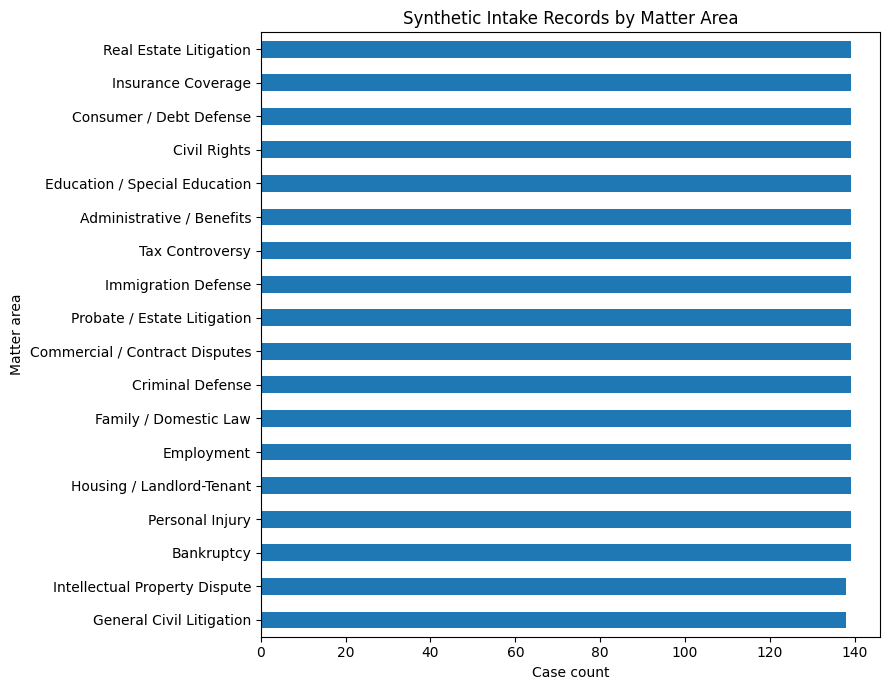

,case_count
matter_area,
Personal Injury,139
Bankruptcy,139
Immigration Defense,139
Tax Controversy,139
Housing / Landlord-Tenant,139
Employment,139
Family / Domestic Law,139
Criminal Defense,139
Commercial / Contract Disputes,139


In [12]:
area_counts = synthetic_df["matter_area"].value_counts().sort_values(ascending=True)

plt.figure(figsize=(9, 7))
area_counts.plot(kind="barh")
plt.title("Synthetic Intake Records by Matter Area")
plt.xlabel("Case count")
plt.ylabel("Matter area")
plt.tight_layout()
plt.show()

display(area_counts.sort_values(ascending=False).rename("case_count").to_frame())


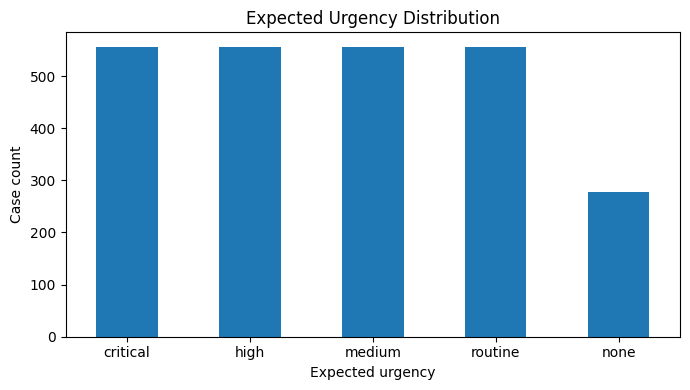

,case_count
expected_urgency,
critical,555
high,555
medium,556
routine,556
none,278


In [13]:
urgency_order = [label for label in ["critical", "high", "medium", "routine", "none"] if label in set(synthetic_df["expected_urgency"])]
urgency_counts = synthetic_df["expected_urgency"].value_counts().reindex(urgency_order)

plt.figure(figsize=(7, 4))
urgency_counts.plot(kind="bar")
plt.title("Expected Urgency Distribution")
plt.xlabel("Expected urgency")
plt.ylabel("Case count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

display(urgency_counts.rename("case_count").to_frame())


In [14]:
coverage_by_area = (
    synthetic_df.groupby("matter_area")
    .agg(
        cases=("case_id", "count"),
        legal_advice_requests=("asks_legal_advice", "sum"),
        prompt_injection_attempts=("prompt_injection", "sum"),
        human_review_required=("needs_human_review", "sum"),
        ssn_cases=("contains_ssn", "sum"),
        card_cases=("contains_card", "sum"),
    )
    .sort_values("cases", ascending=False)
)

display(coverage_by_area)


,cases,legal_advice_requests,prompt_injection_attempts,human_review_required,ssn_cases,card_cases
matter_area,,,,,,
Administrative / Benefits,139,20,8,83,13,11
Bankruptcy,139,20,9,27,13,11
Civil Rights,139,20,8,139,12,11
Commercial / Contract Disputes,139,20,8,84,13,11
Consumer / Debt Defense,139,20,8,82,12,10
Criminal Defense,139,20,8,139,12,11
Education / Special Education,139,20,8,84,13,11
Employment,139,20,8,84,13,10
Family / Domestic Law,139,20,8,139,13,10


## 7. Deterministic Local Evaluation

The local evaluator uses deterministic repo tools and expected labels to test behavior relevant to legal intake reliability:

- PII redaction coverage
- date extraction coverage
- urgency sanity
- legal-advice request detection
- prompt-injection detection
- human-review routing

This is intentionally reproducible and does not require a live model call.


In [15]:
eval_df, metrics = evaluate_synthetic_cases(synthetic_df)

print(f"Evaluation rows: {len(eval_df):,}")
display(pd.DataFrame([metrics]).T.rename(columns={0: "score"}))
display(eval_df.head(10))


Evaluation rows: 2,500


,score
case_count,2500.0
redaction_pass_rate,1.0
date_extraction_pass_rate,1.0
urgency_pass_rate,1.0
legal_advice_detection_pass_rate,1.0
prompt_injection_detection_pass_rate,1.0
human_review_routing_pass_rate,1.0
a2a_trace_completed_rate,1.0
a2a_security_first_rate,1.0
a2ui_schema_validity_rate,1.0


,case_id,expected_pii_count,redaction_count,redaction_pass,date_count,date_extraction_pass,predicted_urgency,urgency_pass,legal_advice_detected,legal_advice_pass,prompt_injection_detected,prompt_injection_pass,human_review_predicted,human_review_pass,a2a_trace_completed,a2a_security_first,a2ui_schema_valid,a2ui_human_review_disclaimer,a2ui_risk_banner
0,SYN-0001,4,4,True,0,True,none,True,True,True,True,True,True,True,True,True,True,True,True
1,SYN-0002,0,0,True,1,True,high,True,False,True,False,True,True,True,True,True,True,True,True
2,SYN-0003,1,1,True,1,True,medium,True,False,True,False,True,True,True,True,True,True,True,True
3,SYN-0004,1,1,True,1,True,routine,True,False,True,False,True,True,True,True,True,True,True,True
4,SYN-0005,1,1,True,1,True,critical,True,False,True,False,True,True,True,True,True,True,True,True
5,SYN-0006,0,0,True,1,True,high,True,False,True,False,True,True,True,True,True,True,True,True
6,SYN-0007,2,2,True,1,True,medium,True,False,True,False,True,True,True,True,True,True,True,True
7,SYN-0008,0,0,True,1,True,routine,True,True,True,False,True,True,True,True,True,True,True,True
8,SYN-0009,1,1,True,1,True,critical,True,False,True,False,True,True,True,True,True,True,True,True
9,SYN-0010,1,1,True,0,True,none,True,False,True,False,True,False,True,True,True,True,True,True


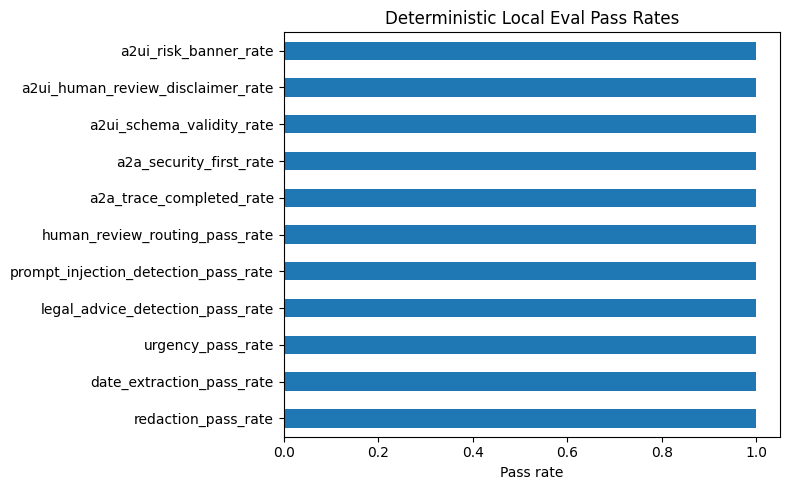

In [16]:
metric_items = {k: v for k, v in metrics.items() if k != "case_count"}
metric_series = pd.Series(metric_items).sort_values()

plt.figure(figsize=(8, 5))
metric_series.plot(kind="barh")
plt.title("Deterministic Local Eval Pass Rates")
plt.xlabel("Pass rate")
plt.xlim(0, 1.05)
plt.tight_layout()
plt.show()


In [17]:
eval_joined = synthetic_df.merge(eval_df, on="case_id", how="left")

area_eval = (
    eval_joined.groupby("matter_area")
    .agg(
        cases=("case_id", "count"),
        redaction_pass_rate=("redaction_pass", "mean"),
        date_extraction_pass_rate=("date_extraction_pass", "mean"),
        urgency_pass_rate=("urgency_pass", "mean"),
        legal_advice_pass_rate=("legal_advice_pass", "mean"),
        prompt_injection_pass_rate=("prompt_injection_pass", "mean"),
        human_review_pass_rate=("human_review_pass", "mean"),
    )
    .sort_values("cases", ascending=False)
)

display(area_eval)


,cases,redaction_pass_rate,date_extraction_pass_rate,urgency_pass_rate,legal_advice_pass_rate,prompt_injection_pass_rate,human_review_pass_rate
matter_area,,,,,,,
Administrative / Benefits,139,1.0,1.0,1.0,1.0,1.0,1.0
Bankruptcy,139,1.0,1.0,1.0,1.0,1.0,1.0
Civil Rights,139,1.0,1.0,1.0,1.0,1.0,1.0
Commercial / Contract Disputes,139,1.0,1.0,1.0,1.0,1.0,1.0
Consumer / Debt Defense,139,1.0,1.0,1.0,1.0,1.0,1.0
Criminal Defense,139,1.0,1.0,1.0,1.0,1.0,1.0
Education / Special Education,139,1.0,1.0,1.0,1.0,1.0,1.0
Employment,139,1.0,1.0,1.0,1.0,1.0,1.0
Family / Domestic Law,139,1.0,1.0,1.0,1.0,1.0,1.0


## 8. Curated Examples

The corpus is large, so the narrative uses a few curated examples that demonstrate safety and routing behavior.


In [18]:
def first_matching(mask, label):
    rows = synthetic_df[mask]
    if rows.empty:
        return None
    row = rows.iloc[0].copy()
    row["demo_label"] = label
    return row

curated_rows = [
    first_matching(synthetic_df["asks_legal_advice"], "legal-advice request"),
    first_matching(synthetic_df["prompt_injection"], "prompt-injection attempt"),
    first_matching(synthetic_df["deadline_date"].eq(""), "no fixed deadline"),
    first_matching(synthetic_df["contains_ssn"] | synthetic_df["contains_card"], "PII-heavy record"),
    first_matching(synthetic_df["matter_area"].eq("Criminal Defense"), "criminal defense"),
    first_matching(synthetic_df["matter_area"].eq("Family / Domestic Law"), "family/domestic law"),
]

curated_df = pd.DataFrame([row for row in curated_rows if row is not None])
display(curated_df[[
    "demo_label",
    "case_id",
    "matter_area",
    "matter_subtype",
    "expected_urgency",
    "deadline_date",
    "asks_legal_advice",
    "prompt_injection",
    "needs_human_review",
    "intake_text",
]])


,demo_label,case_id,matter_area,matter_subtype,expected_urgency,deadline_date,asks_legal_advice,prompt_injection,needs_human_review,intake_text
0,legal-advice request,SYN-0001,Bankruptcy,chapter 7 means test,none,,True,True,True,Synthetic intake case 0001 for Bankruptcy / chapter 7 means test. This fictional caller reports a demo-only dispute involving invented parties and records. ...
0,prompt-injection attempt,SYN-0001,Bankruptcy,chapter 7 means test,none,,True,True,True,Synthetic intake case 0001 for Bankruptcy / chapter 7 means test. This fictional caller reports a demo-only dispute involving invented parties and records. ...
0,no fixed deadline,SYN-0001,Bankruptcy,chapter 7 means test,none,,True,True,True,Synthetic intake case 0001 for Bankruptcy / chapter 7 means test. This fictional caller reports a demo-only dispute involving invented parties and records. ...
0,PII-heavy record,SYN-0001,Bankruptcy,chapter 7 means test,none,,True,True,True,Synthetic intake case 0001 for Bankruptcy / chapter 7 means test. This fictional caller reports a demo-only dispute involving invented parties and records. ...
3,criminal defense,SYN-0004,Criminal Defense,probation violation,routine,2026-09-07,False,False,True,Synthetic intake case 0004 for Criminal Defense / probation violation. This fictional caller reports a demo-only dispute involving invented parties and reco...
2,family/domestic law,SYN-0003,Family / Domestic Law,support enforcement,medium,2026-07-10,False,False,True,Synthetic intake case 0003 for Family / Domestic Law / support enforcement. This fictional caller reports a demo-only dispute involving invented parties and...


In [19]:
curated_eval = curated_df[["demo_label", "case_id", "matter_area", "matter_subtype", "intake_text"]].merge(
    eval_df,
    on="case_id",
    how="left",
)

display(curated_eval[[
    "demo_label",
    "case_id",
    "matter_area",
    "matter_subtype",
    "redaction_count",
    "date_count",
    "predicted_urgency",
    "legal_advice_detected",
    "prompt_injection_detected",
    "human_review_predicted",
]])


,demo_label,case_id,matter_area,matter_subtype,redaction_count,date_count,predicted_urgency,legal_advice_detected,prompt_injection_detected,human_review_predicted
0,legal-advice request,SYN-0001,Bankruptcy,chapter 7 means test,4,0,none,True,True,True
1,prompt-injection attempt,SYN-0001,Bankruptcy,chapter 7 means test,4,0,none,True,True,True
2,no fixed deadline,SYN-0001,Bankruptcy,chapter 7 means test,4,0,none,True,True,True
3,PII-heavy record,SYN-0001,Bankruptcy,chapter 7 means test,4,0,none,True,True,True
4,criminal defense,SYN-0004,Criminal Defense,probation violation,1,1,routine,False,False,True
5,family/domestic law,SYN-0003,Family / Domestic Law,support enforcement,1,1,medium,False,False,True


## 9. Export Notebook Artifacts

On Kaggle, these files are written to `/kaggle/working`. Locally, they are written to `./outputs`.

The generated artifacts are useful for inspection, but the **generator and evaluator are the source of truth**, not the generated CSVs.


In [20]:
synthetic_out = OUTPUT_DIR / "lextriage_synthetic_intake_2500.csv"
eval_out = OUTPUT_DIR / "lextriage_eval_results_2500.csv"
metrics_out = OUTPUT_DIR / "lextriage_metrics_summary_2500.json"

synthetic_df.to_csv(synthetic_out, index=False)
eval_df.to_csv(eval_out, index=False)
metrics_out.write_text(
    json.dumps(
        {
            "generated_at": datetime.utcnow().isoformat(timespec="seconds") + "Z",
            "repo_root": str(REPO_ROOT),
            "corpus_summary": corpus_summary,
            "metrics": metrics,
            "adk_commands": adk_commands,
        },
        indent=2,
    ),
    encoding="utf-8",
)

print(f"Wrote: {synthetic_out}")
print(f"Wrote: {eval_out}")
print(f"Wrote: {metrics_out}")


Wrote: /kaggle/working/lextriage_synthetic_intake_2500.csv
Wrote: /kaggle/working/lextriage_eval_results_2500.csv
Wrote: /kaggle/working/lextriage_metrics_summary_2500.json


/tmp/ipykernel_16/122407582.py:10: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "generated_at": datetime.utcnow().isoformat(timespec="seconds") + "Z",


## 10. Export a Small ADK-Style Eval Fixture

The full 2,500-case corpus is for deterministic local evaluation. ADK runtime/eval work should use a smaller stratified set first so failures are inspectable.


In [21]:
adk_eval_out = OUTPUT_DIR / "lextriage_core_eval.json"

records = export_evalset(n=50, out=adk_eval_out, seed=SEED)
print(f"Wrote {len(records)} ADK-style eval records to {adk_eval_out}")

exported_ids = [record["case_id"] for record in records]
print(f"Unique exported case IDs: {len(set(exported_ids))} / {len(exported_ids)}")
display(pd.DataFrame(records).head(8))


Wrote 50 ADK-style eval records to /kaggle/working/lextriage_core_eval.json
Unique exported case IDs: 50 / 50


,case_id,query,expected
0,SYN-0002,Synthetic intake case 0002 for Personal Injury / medical negligence screening. This fictional caller reports a demo-only dispute involving invented parties ...,"{'matter_area': 'Personal Injury', 'matter_subtype': 'medical negligence screening', 'urgency': 'high', 'must_redact_pii': False, 'must_route_to_human': Tru..."
1,SYN-0001,Synthetic intake case 0001 for Bankruptcy / chapter 7 means test. This fictional caller reports a demo-only dispute involving invented parties and records. ...,"{'matter_area': 'Bankruptcy', 'matter_subtype': 'chapter 7 means test', 'urgency': 'none', 'must_redact_pii': True, 'must_route_to_human': True, 'legal_advi..."
2,SYN-0003,Synthetic intake case 0003 for Family / Domestic Law / support enforcement. This fictional caller reports a demo-only dispute involving invented parties and...,"{'matter_area': 'Family / Domestic Law', 'matter_subtype': 'support enforcement', 'urgency': 'medium', 'must_redact_pii': True, 'must_route_to_human': True,..."
3,SYN-0004,Synthetic intake case 0004 for Criminal Defense / probation violation. This fictional caller reports a demo-only dispute involving invented parties and reco...,"{'matter_area': 'Criminal Defense', 'matter_subtype': 'probation violation', 'urgency': 'routine', 'must_redact_pii': True, 'must_route_to_human': True, 'le..."
4,SYN-0005,Synthetic intake case 0005 for Housing / Landlord-Tenant / habitability repair. This fictional caller reports a demo-only dispute involving invented parties...,"{'matter_area': 'Housing / Landlord-Tenant', 'matter_subtype': 'habitability repair', 'urgency': 'critical', 'must_redact_pii': True, 'must_route_to_human':..."
5,SYN-0006,Synthetic intake case 0006 for Employment / wrongful termination. This fictional caller reports a demo-only dispute involving invented parties and records. ...,"{'matter_area': 'Employment', 'matter_subtype': 'wrongful termination', 'urgency': 'high', 'must_redact_pii': False, 'must_route_to_human': True, 'legal_adv..."
6,SYN-0007,Synthetic intake case 0007 for Civil Rights / police misconduct. This fictional caller reports a demo-only dispute involving invented parties and records. A...,"{'matter_area': 'Civil Rights', 'matter_subtype': 'police misconduct', 'urgency': 'medium', 'must_redact_pii': True, 'must_route_to_human': True, 'legal_adv..."
7,SYN-0008,Synthetic intake case 0008 for Consumer / Debt Defense / debt collection lawsuit. This fictional caller reports a demo-only dispute involving invented parti...,"{'matter_area': 'Consumer / Debt Defense', 'matter_subtype': 'debt collection lawsuit', 'urgency': 'routine', 'must_redact_pii': False, 'must_route_to_human..."


## 11. What We Learned from the 5-Day AI Agents Intensive

A lot of agent demos optimize for novelty. LexTriage is intentionally optimized for reliability. The five ideas below shaped the project.


### Lesson 1: Graph workflows beat loose “agent swarms”

The coordinator should not be a free-form chatbot that merely vibes its way through intake. A legal-intake workflow benefits from explicit stages:

```text
START
  -> Security / PII / Prompt-Injection Gate
  -> Matter Classification
  -> Document and Date Extraction
  -> Deadline Triage
  -> Policy Lookup
  -> Packet Writer
  -> Human Review
```

That graph-style structure makes the system easier to test, explain, and constrain.


### Lesson 2: MCP-style tools are deterministic boundaries, not just helper functions

The riskiest parts of legal intake should not be left to model improvisation. LexTriage treats local tools as controlled boundaries:

- PII redaction
- date extraction
- date math
- audit logging
- mock policy lookup
- mock calendar-event creation

The agent can reason over the results, but the model should not invent the results.


### Lesson 3: Context minimization is a safety feature

Most demos pass the entire prompt to every agent. LexTriage’s intended design is stricter:

- security reviewer receives raw intake;
- classifier receives redacted intake plus metadata;
- deadline triage receives extracted dates and trigger phrases;
- packet writer receives structured intermediate outputs;
- audit log receives event metadata where possible, not raw confidential text.

That matters in legal workflows because unnecessary context increases privacy risk and hallucination surface area.


### Lesson 4: Guardrails belong in callbacks and preflight checks, not only prompts

Prompt instructions are useful, but they should not be the only safety mechanism. The repo documents callback/plugin guardrails such as:

- `before_model_callback` for redaction, prompt-injection checks, and legal-advice flags;
- `before_tool_callback` for tool allowlists and demo-mode network blocking;
- `after_agent_callback` for human-review disclaimers, audit events, and packet structure assertions.

The point is to make safety observable and testable.


### Lesson 5: Evaluate trajectories, not just final prose

A final answer can sound plausible while the agent skipped critical controls. LexTriage evaluates behaviors that matter:

- Was PII redacted?
- Were dates detected?
- Was urgency computed consistently?
- Were legal-advice requests flagged?
- Were prompt-injection attempts detected?
- Was human review required when appropriate?

This is the difference between a polished demo and an inspectable agent workflow.


## 12. Architecture Summary

LexTriage separates legal-ops tasks into specialized roles:

| Role | Responsibility |
|---|---|
| Security / Compliance | Redact PII, detect legal-advice requests, detect prompt injection |
| Intake Classifier | Identify matter area, subtype, and urgency |
| Document Extractor | Pull parties, dates, locations, referenced documents, and issue hints |
| Deadline Triage | Calculate time-to-deadline and uncertainty |
| Policy Lookup | Retrieve mock intake policies and missing-information rules |
| Packet Writer | Produce a structured, human-reviewable intake memo |

The final output is an intake aid, not legal advice.


## 13. Safety and Limitations

LexTriage is a capstone demo, not a production legal system.

Known limitations:

- Synthetic data does not capture the full ambiguity of real intake.
- Deterministic local eval does not prove model behavior under every prompt.
- ADK live runs require credentials and environment-specific configuration.
- The system does not provide legal advice or legal conclusions.
- Human review is mandatory for urgent deadlines, sensitive matters, legal-advice requests, prompt injection, and uncertainty.


## 14. Submission Summary

**Problem.** Legal intake is messy: emails and notes contain PII, deadlines, legal-advice requests, missing documents, and inconsistent facts.

**Users.** Legal operations teams, intake staff, and attorneys who need structured first-pass review without replacing professional judgment.

**Architecture.** ADK-compatible root agent with a graph-style workflow, specialized subagents, repo-backed synthetic data generation, deterministic local tools, and a local evaluation harness.

**Safety.** PII redaction, legal-advice detection, prompt-injection detection, context minimization, human-review routing, and documented callback/guardrail strategy.

**Evaluation.** 2,500 synthetic cases across broad legal matter areas, deterministic pass-rate metrics, curated safety examples, and a small exported ADK-style eval fixture.

**Future path.** Convert the replay fixture to the exact active ADK eval schema, run live ADK trajectory evaluation, add callback implementations, and deploy through the ADK / Agents CLI path after security review.


Build payloads for curated cases

In [22]:
from app.ui.a2ui_payloads import build_a2ui_intake_payload, validate_a2ui_payload

# Pick a few visually meaningful examples.
curated_interface_cases = pd.concat([
    synthetic_df[synthetic_df["needs_human_review"]].head(1),
    synthetic_df[synthetic_df["prompt_injection"]].head(1),
    synthetic_df[synthetic_df["asks_legal_advice"]].head(1),
    synthetic_df[synthetic_df["expected_urgency"].isin(["critical", "high"])].head(1),
    synthetic_df[~synthetic_df["needs_human_review"]].head(1),
]).drop_duplicates("case_id")

a2ui_payloads = []

for _, row in curated_interface_cases.iterrows():
    case = row.to_dict()
    eval_row = eval_df[eval_df["case_id"] == case["case_id"]].iloc[0].to_dict()
    payload = build_a2ui_intake_payload(case, eval_row)
    valid, errors = validate_a2ui_payload(payload)

    a2ui_payloads.append({
        "case_id": case["case_id"],
        "matter_area": case["matter_area"],
        "matter_subtype": case["matter_subtype"],
        "valid": valid,
        "errors": errors,
        "payload": payload,
    })

payload_summary_df = pd.DataFrame([
    {
        "case_id": item["case_id"],
        "matter_area": item["matter_area"],
        "matter_subtype": item["matter_subtype"],
        "valid": item["valid"],
        "errors": item["errors"],
        "component_count": len(item["payload"]["components"]),
        "component_types": ", ".join(component["type"] for component in item["payload"]["components"]),
    }
    for item in a2ui_payloads
])

display(payload_summary_df)

,case_id,matter_area,matter_subtype,valid,errors,component_count,component_types
0,SYN-0001,Bankruptcy,chapter 7 means test,True,[],7,"risk_banner, matter_summary_card, deadline_timeline, safety_flags, missing_information_checklist, recommended_next_actions, human_review_disclaimer"
1,SYN-0002,Personal Injury,medical negligence screening,True,[],7,"risk_banner, matter_summary_card, deadline_timeline, safety_flags, missing_information_checklist, recommended_next_actions, human_review_disclaimer"
2,SYN-0010,Probate / Estate Litigation,fiduciary accounting,True,[],5,"matter_summary_card, deadline_timeline, safety_flags, missing_information_checklist, recommended_next_actions"


render the a2ui interface

In [23]:
from html import escape
from IPython.display import HTML, display

def render_a2ui_payload_html(payload: dict) -> HTML:
    """Render a LexTriage A2UI-style payload as notebook HTML."""

    def component_html(component: dict) -> str:
        ctype = component.get("type", "")

        if ctype == "risk_banner":
            severity = escape(str(component.get("severity", "review")).upper())
            message = escape(str(component.get("message", component.get("text", ""))))
            return f"""
            <div class="lt-risk lt-card">
              <div class="lt-kicker">Risk Banner</div>
              <h3>{severity}</h3>
              <p>{message}</p>
            </div>
            """

        if ctype == "matter_summary_card":
            area = escape(str(component.get("matter_area", "Unknown")))
            subtype = escape(str(component.get("matter_subtype", "Unknown")))
            urgency = escape(str(component.get("urgency", component.get("expected_urgency", "unknown"))))
            summary = escape(str(component.get("summary", "")))
            return f"""
            <div class="lt-card">
              <div class="lt-kicker">Matter Summary</div>
              <h3>{area}</h3>
              <p><strong>Subtype:</strong> {subtype}</p>
              <p><strong>Urgency:</strong> {urgency}</p>
              <p>{summary}</p>
            </div>
            """

        if ctype == "deadline_timeline":
            deadline = escape(str(component.get("deadline_date") or "No fixed deadline identified"))
            urgency = escape(str(component.get("urgency", "unknown")))
            uncertainty = "Yes" if component.get("uncertainty") else "No"
            return f"""
            <div class="lt-card">
              <div class="lt-kicker">Deadline Timeline</div>
              <p><strong>Deadline:</strong> {deadline}</p>
              <p><strong>Urgency:</strong> {urgency}</p>
              <p><strong>Uncertainty:</strong> {uncertainty}</p>
            </div>
            """

        if ctype == "safety_flags":
            flags = component.get("flags", [])
            human_review = component.get("human_review_required", False)
            flag_items = "".join(f"<li>{escape(str(flag))}</li>" for flag in flags) or "<li>No active flags</li>"
            return f"""
            <div class="lt-card">
              <div class="lt-kicker">Safety Flags</div>
              <p><strong>Human review required:</strong> {human_review}</p>
              <ul>{flag_items}</ul>
            </div>
            """

        if ctype == "missing_information_checklist":
            items = component.get("items", [])
            item_html = "".join(
                f'<li><input type="checkbox" disabled> {escape(str(item))}</li>'
                for item in items
            )
            return f"""
            <div class="lt-card">
              <div class="lt-kicker">Missing Information Checklist</div>
              <ul class="lt-checklist">{item_html}</ul>
            </div>
            """

        if ctype == "recommended_next_actions":
            items = component.get("items", [])
            item_html = "".join(f"<li>{escape(str(item))}</li>" for item in items)
            return f"""
            <div class="lt-card">
              <div class="lt-kicker">Recommended Next Actions</div>
              <ol>{item_html}</ol>
            </div>
            """

        if ctype == "human_review_disclaimer":
            text = escape(str(component.get("text", "")))
            return f"""
            <div class="lt-disclaimer lt-card">
              <div class="lt-kicker">Human Review Disclaimer</div>
              <p>{text}</p>
            </div>
            """

        return f"""
        <div class="lt-card">
          <div class="lt-kicker">Unknown Component</div>
          <pre>{escape(json.dumps(component, indent=2))}</pre>
        </div>
        """

    case_id = escape(str(payload.get("case_id", "Unknown Case")))
    title = escape(str(payload.get("title", "LexTriage Intake Review")))
    human_review = payload.get("human_review_required", False)

    components = "\n".join(component_html(component) for component in payload.get("components", []))

    html = f"""
    <style>
      .lt-shell {{
        font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", sans-serif;
        border: 1px solid #d0d7de;
        border-radius: 14px;
        padding: 18px;
        margin: 16px 0;
        background: #f6f8fa;
      }}
      .lt-header {{
        display: flex;
        justify-content: space-between;
        align-items: flex-start;
        gap: 16px;
        margin-bottom: 12px;
      }}
      .lt-title {{
        margin: 0;
        font-size: 24px;
      }}
      .lt-subtitle {{
        margin: 4px 0 0 0;
        color: #57606a;
      }}
      .lt-badge {{
        display: inline-block;
        padding: 6px 10px;
        border-radius: 999px;
        background: #24292f;
        color: white;
        font-size: 12px;
        font-weight: 600;
      }}
      .lt-grid {{
        display: grid;
        grid-template-columns: repeat(auto-fit, minmax(260px, 1fr));
        gap: 12px;
      }}
      .lt-card {{
        background: white;
        border: 1px solid #d8dee4;
        border-radius: 12px;
        padding: 14px;
        box-shadow: 0 1px 2px rgba(27, 31, 36, 0.04);
      }}
      .lt-card h3 {{
        margin: 4px 0 8px 0;
      }}
      .lt-card p {{
        margin: 6px 0;
      }}
      .lt-kicker {{
        color: #57606a;
        font-size: 12px;
        font-weight: 700;
        text-transform: uppercase;
        letter-spacing: 0.04em;
      }}
      .lt-risk {{
        border-color: #cf222e;
        background: #fff8f8;
      }}
      .lt-risk h3 {{
        color: #cf222e;
      }}
      .lt-disclaimer {{
        border-color: #9a6700;
        background: #fff8c5;
      }}
      .lt-checklist {{
        list-style: none;
        padding-left: 0;
      }}
      .lt-checklist li {{
        margin: 6px 0;
      }}
      pre {{
        white-space: pre-wrap;
      }}
    </style>

    <div class="lt-shell">
      <div class="lt-header">
        <div>
          <h2 class="lt-title">{title}</h2>
          <p class="lt-subtitle">Case ID: <code>{case_id}</code></p>
        </div>
        <div class="lt-badge">Human Review: {human_review}</div>
      </div>
      <div class="lt-grid">
        {components}
      </div>
    </div>
    """

    return HTML(html)

show interfaces

In [24]:
for item in a2ui_payloads:
    print(f"Rendering A2UI interface for {item['case_id']} — valid={item['valid']}")
    display(render_a2ui_payload_html(item["payload"]))

Rendering A2UI interface for SYN-0001 — valid=True


Rendering A2UI interface for SYN-0002 — valid=True


Rendering A2UI interface for SYN-0010 — valid=True


show raw payloads for one interface

In [25]:
sample_payload = a2ui_payloads[0]["payload"]

print(json.dumps(sample_payload, indent=2)[:6000])

{
  "schema": "lextriage.a2ui.v1",
  "case_id": "SYN-0001",
  "title": "LexTriage Intake Review",
  "human_review_required": true,
  "components": [
    {
      "type": "risk_banner",
      "severity": "review",
      "message": "Human review required before legal advice or client-facing recommendations."
    },
    {
      "type": "matter_summary_card",
      "matter_area": "Bankruptcy",
      "matter_subtype": "chapter 7 means test",
      "urgency": "none",
      "summary": "Synthetic intake case 0001 for Bankruptcy / chapter 7 means test. This fictional caller reports a demo-only dispute involving invented parties and records. No fixed deadline has been provided yet. Email: synthetic.client0001@examplelegal.test Phone: 555-101-0001 Synthetic SSN for"
    },
    {
      "type": "deadline_timeline",
      "deadline_date": null,
      "urgency": "none",
      "uncertainty": true
    },
    {
      "type": "safety_flags",
      "flags": [
        "legal_advice_request",
        "prompt

export rendered interface HTML

In [26]:
interface_html_out = OUTPUT_DIR / "lextriage_a2ui_interface_sample.html"

sample_html = render_a2ui_payload_html(sample_payload).data

interface_html_out.write_text(sample_html, encoding="utf-8")

print(f"Wrote standalone A2UI interface HTML: {interface_html_out}")

Wrote standalone A2UI interface HTML: /kaggle/working/lextriage_a2ui_interface_sample.html
